# Implementation of the Vision Transfrormer (ViT) architecture from scrath.


Vision Transformer (ViT) architecture Implementation from paper "An Image Is Worth 16x16 Words: Transformers for Image Recognition at Scale" by Dosovitskiy et al. (2020).
https://arxiv.org/pdf/2010.11929

In [ ]:
# import the neccessary libraries.
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import collections
from sklearn.model_selection import StratifiedShuffleSplit
import torch
from torch import nn, optim
from torch.nn.modules.utils import _pair
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as transforms_v2
from torchvision import datasets
import torch.optim as optim
import matplotlib.pyplot as plt






from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms, utils, models
from torchsummary import summary


import warnings

# suppress all warnings.
warnings.filterwarnings("ignore")



print("All libraries and modules have been imported!")

All libraries and modules have been imported!


In [ ]:
import sklearn

# print versions of the key libraries used in the project.
print("library Versions:")
print(f"numPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"pyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

library Versions:
numPy version: 2.0.2
pandas version: 2.2.2
scikit-learn version: 1.6.1
pyTorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [ ]:
!pip show torchsummary

Name: torchsummary
Version: 1.5.1
Summary: Model summary in PyTorch similar to `model.summary()` in Keras
Home-page: https://github.com/sksq96/pytorch-summary
Author: Shubham Chandel @sksq96
Author-email: shubham.zeez@gmail.com
License: UNKNOWN
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### **Load the dataset**

In [ ]:
# navigate to your project folder.
import sys
sys.path.append('/content/drive/MyDrive/')

In [ ]:
# define the path to data.
path2data= "/content/drive/MyDrive/vit_project/data"

# check if the path exists.
if not os.path.exists(path2data):
    os.makedirs(path2data, exist_ok=True)


# define the transformation.
data_transformer = transforms.Compose([transforms.ToTensor()])

# Load the train dataset and apply the transformation on the dataset.
train_dataset = torchvision.datasets.STL10(
    root=path2data,
    split="train",
    download=True,
    transform=data_transformer
    )

In [ ]:
# retrieve the training labels.
y_train = [y for x, y in train_dataset]

# count the number of images per category.
counter_train = collections.Counter(y_train)

print(counter_train)

Counter({1: 500, 5: 500, 6: 500, 3: 500, 9: 500, 7: 500, 4: 500, 8: 500, 0: 500, 2: 500})


In [ ]:
# load the STL10 test dataset with a specified data transformation.
val_test_dataset = datasets.STL10(
    path2data,
    split='test',
    download=True,
    transform=data_transformer
)

# initialize StratifiedShuffleSplit to create a stratified split for validation and test sets.
sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=2024
)

# get the indices of the entire dataset.
indices = list(range(len(val_test_dataset)))

# extract the labels (y) for stratified splitting.
val_test_y = [y for _, y in val_test_dataset]

# perform the stratified split
for test_index, val_index in sss.split(indices, val_test_y):

    # print the resulting indices for debugging or verification.
    print("Test indices:", test_index)
    print("Validation indices:", val_index)
    print(f"Number of validation samples: {len(val_index)}")
    print(f"Number of test samples: {len(test_index)}")


# create validation and test datasets using the split indices.
val_dataset = Subset(val_test_dataset, val_index)
test_dataset = Subset(val_test_dataset, test_index)

Test indices: [1712 6132  661 ... 4977 2532 7397]
Validation indices: [4565 4173 3052 ... 4858 7191 3296]
Number of validation samples: 1600
Number of test samples: 6400


In [ ]:
# extract the labels from the validation dataset.
y_test = [y for _, y in val_dataset]
y_val = [y for _, y in val_dataset]

# count the occurrences of each label in the test and validation datasets.
counter_test = collections.Counter(y_test)
counter_val = collections.Counter(y_val)

# print the label distributions for debugging or analysis.
print("Label distribution in the test set:", counter_test)
print("Label distribution in the validation set:", counter_val)

Label distribution in the test set: Counter({7: 160, 6: 160, 2: 160, 0: 160, 4: 160, 1: 160, 3: 160, 5: 160, 9: 160, 8: 160})
Label distribution in the validation set: Counter({7: 160, 6: 160, 2: 160, 0: 160, 4: 160, 1: 160, 3: 160, 5: 160, 9: 160, 8: 160})


### **Let's visualize the dataset.**

In [ ]:
def show_image(img, y=None, color=True):
    """
    Display an image using matplotlib.

    Parameters:
    img (Tensor): The image tensor to be displayed. Expected shape (C, H, W).
    y (int or str, optional): The label associated with the image. Default is None.
    color (bool, optional): Determines if the image should be displayed in color. Default is True.

    Behavior:
    - Converts the PyTorch tensor to a NumPy array and transposes it to match the shape expected by matplotlib (H, W, C).
    - Displays the image using `plt.imshow`.
    - If a label (`y`) is provided, it is displayed as the title of the image.
    """

    # convert the PyTorch tensor to a NumPy array.
    np_img = img.numpy()

    # transpose dimensions to match matplotlib's expected input shape (H, W, C).
    np_img_transpose = np.transpose(np_img, (1, 2, 0))

    # display the image.
    plt.imshow(np_img_transpose)

    # display the label as a title, if provided.
    if y is not None:
        plt.title("Label: " + str(y))

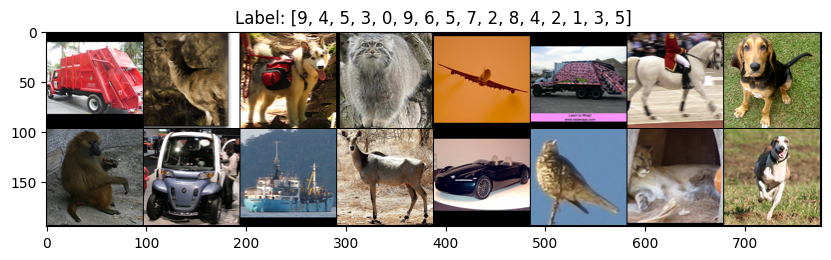

In [ ]:
# define the grid size for displaying multiple images.
grid_size = 16

# for images reproducibility
np.random.seed(2024)

# select random indices from the training dataset for visualization.
random_inds = np.random.randint(0, len(train_dataset), grid_size)

# extract the images and labels corresponding to the random indices.
x_grid = [train_dataset[i][0] for i in random_inds]
y_grid = [train_dataset[i][1] for i in random_inds]

# create a grid of images using torchvision's utility.
x_grid = utils.make_grid(x_grid, nrow=8, padding=1)

# set the figure size for better visualization.
plt.figure(figsize=(10, 10))

# call the helper function to display the grid of images.
show_image(x_grid, y_grid)

In [ ]:
def calculate_image_mean_std(train_dataset, gray_scale=False):
    """
    Calculate the mean and standard deviation of a dataset of images.

    Parameters:
    -----------
    train_dataset : Dataset
        A dataset containing image-label pairs, where each image is assumed
        to be a PyTorch tensor with shape (C, H, W).
    gray_scale : bool, optional
        If True, the function assumes grayscale images and calculates statistics accordingly.
        If False, it calculates statistics for RGB channels separately.

    Returns:
    --------
    tuple
        A tuple containing two elements:
        - A tuple of means for each channel (e.g., (mean_R, mean_G, mean_B) or (mean,)).
        - A tuple of standard deviations for each channel (e.g., (std_R, std_G, std_B) or (std,)).
    """

    # calculate mean values for each channel.
    mean_RGB = [np.mean(a=x.numpy(), axis=(1, 2)) for x, y in train_dataset]

    mean_R = np.mean([m[0] for m in mean_RGB])
    mean_G = np.mean([m[1] for m in mean_RGB])
    mean_B = np.mean([m[2] for m in mean_RGB])

    # calculate standard deviation for each channel.
    std_RGB = [np.std(a=x.numpy(), axis=(1, 2)) for x, y in train_dataset]
    std_R = np.mean([s[0] for s in std_RGB])
    std_G = np.mean([s[1] for s in std_RGB])
    std_B = np.mean([s[2] for s in std_RGB])

    # return grayscale statistics if specified.
    if gray_scale:
        mean_gray = np.mean([np.mean(m) for m in mean_RGB])
        std_gray = np.mean([np.mean(s) for s in std_RGB])
        return (mean_gray,), (std_gray,)

    # return RGB statistics.
    return (mean_R, mean_G, mean_B), (std_R, std_G, std_B)

**get the mean and standard deviation from the training dataset.**

In [ ]:
# get the mean and standard deviation of the training dataset.
mean_rgb, std_rgb = calculate_image_mean_std(train_dataset)

For this image training dataset, the mean RGB is (0.4467, 0.4398, 0.4066) and the standard deviation RGB is (0.2241, 0.2215, 0.2239).

In [ ]:
# define the transformation pipeline for the training dataset.
train_transformer = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        [mean_rgb[0], mean_rgb[1], mean_rgb[2]],
        [std_rgb[0], std_rgb[1], std_rgb[2]]
    )
])

# define the transformation pipeline for the validation and test datasets.
val_test_transformer = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(
        [mean_rgb[0], mean_rgb[1], mean_rgb[2]],
        [std_rgb[0], std_rgb[1], std_rgb[2]]
    )
])

# assign training transformations (if intentional, otherwise adjust).
train_dataset.transform = train_transformer

# overwrite with validation/test transformations.
val_test_dataset.transform = val_test_transformer

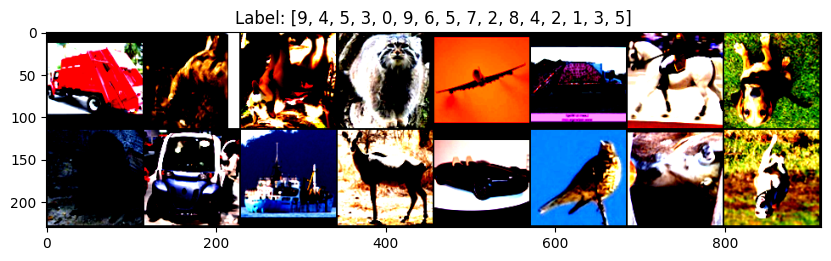

In [ ]:
np.random.seed(2024)
torch.manual_seed(2024)

grid_size = 16
random_inds = np.random.randint(0,len(train_dataset), grid_size)

x_grid = [train_dataset[i][0] for i in random_inds]
y_grid = [train_dataset[i][1] for i in random_inds]

x_grid = utils.make_grid(x_grid, nrow=8, padding=2)


plt.figure(figsize=(10,10))
show_image(x_grid,y_grid)

In [ ]:
# create a DataLoader for the training dataset.
train_data_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# create a DataLoader for the validation dataset.
val_data_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

# MODEL ARCHITECTURE

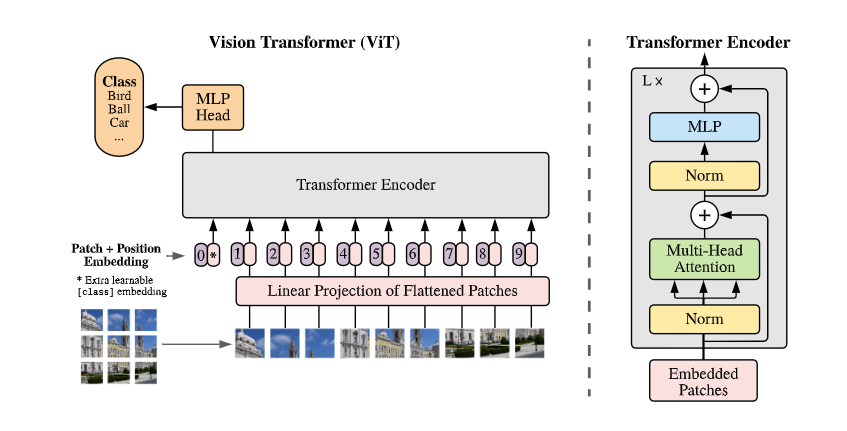

### Patch Embedding

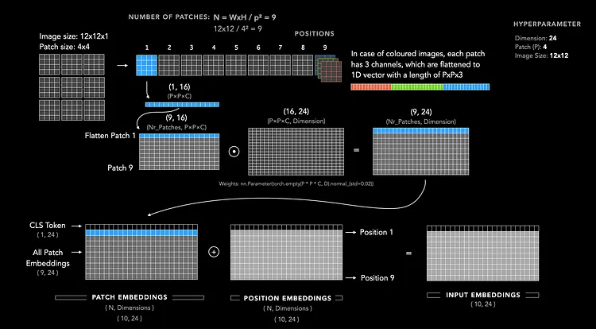

The code implementation of Patch Embedding section is written below.

In [ ]:
class PatchEmbed(nn.Module):
    """projects image patches into embeddings, appends cls token, and adds positional encodings."""

    def __init__(self, config, img_size, in_channels=3):
        """initializes patch projection, cls token, positional embeddings, and dropout."""
        super().__init__()

        patch_size = _pair(config.get("patch_size", 16))
        img_size = _pair(img_size)
        embed_dim = config.get("embed_dim", 768)
        dropout_rate = config.get("dropo_ut", 0.1)

        self.patch_size = patch_size
        self.img_size = img_size
        self.embed_dim = embed_dim

        # conv2d projects patches: (B, C, H, W) -> (B, embed_dim, n_h, n_w), flattened in forward.
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
            padding=0,
        )

        num_patches = PatchEmbed.num_patches(img_size[0], patch_size[0])

        # +1 position for the cls token.
        num_positions = num_patches + 1

        # learnable cls token.
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim), requires_grad=True)

        # learnable positional embeddings.
        self.position_embeddings = nn.Parameter(torch.randn(1, num_positions, embed_dim), requires_grad=True)

        self.dropout = nn.Dropout(p=dropout_rate)

    @staticmethod
    def num_patches(img_size, patch_size=16):
        """computes number of patches: n = (h * w) / p² for a square image."""

        return (img_size // patch_size) ** 2

    def forward(self, x):
        """embeds input image into patch tokens with cls token and positional encodings."""

        if x.dim() == 3:
            x = x.unsqueeze(0)

        B, _, H, W = x.shape
        patch_size_h, patch_size_w = self.patch_size

        assert H % patch_size_h == 0 and W % patch_size_w == 0, (
            f"image size ({H}, {W}) not divisible by patch size {self.patch_size}"
        )

        # flatten spatial dims and transpose: (B, embed_dim, n_patches) -> (B, n_patches, embed_dim).
        patch_embeddings = self.proj(x).flatten(2).permute(0, 2, 1)

        # expand cls token across batch and prepend to patch embeddings.
        cls_tokens = self.cls_token.expand(B, -1, -1)
        embeddings = torch.cat((cls_tokens, patch_embeddings), dim=1)

        # add positional encodings and apply dropout.
        embeddings = embeddings + self.position_embeddings

        # apply droupout to embeddings.
        embeddings = self.dropout(embeddings)

        return embeddings

In [ ]:
class MLP(nn.Module):
    """multi-layer perceptron for the vision transformer (vit)."""

    def __init__(self, input_size, hidden_size, output_size, dropout):
        """initializes two linear layers with gelu activation and dropout."""
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout = dropout

        # two-layer mlp with gelu activation.
        self.layers = nn.Sequential(
            nn.Linear(self.input_size, self.hidden_size),
            nn.GELU(),
            nn.Dropout(self.dropout),
            nn.Linear(self.hidden_size, self.output_size),
            nn.Dropout(self.dropout),
        )

        # initialize weights after layers are defined.
        self._init_weights()

    def _init_weights(self):
        """initializes weights with xavier uniform and biases near zero."""

        for module in self.layers:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.normal_(module.bias, std=1e-6)

    def forward(self, x):
        """passes input through the mlp layers."""

        return self.layers(x)

In [ ]:
class MultiHeadAttention(nn.Module):
    """multi-head attention mechanism with multiple parallel attention heads for the vision transformer (ViT)."""

    def __init__(self, d_in, d_out, dropout, num_heads, qkv_bias=False):
        """initialize the multi-head attention layer."""

        super().__init__()

        # ensure output dimension is divisible by number of heads.
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        # store dimensions.
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        # query projection layer.
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)

        # key projection layer.
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)

        # value projection layer.
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # output projection to combine heads.
        self.out_proj = nn.Linear(d_out, d_out)

        # dropout layer.
        self.dropout = nn.Dropout(dropout)


    def forward(self, x):
        """applies multi-head attention to input sequence."""

        # get batch size, sequence length, and input dimension.
        b, num_tokens, d_in = x.shape

        # compute queries, keys, and values.
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # split into multiple heads by reshaping.
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # rearrange to (batch, num_heads, seq_len, head_dim).
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # compute attention scores.
        attn_scores = queries @ keys.transpose(2, 3)

        # apply causal mask to prevent attending to future tokens.
        # mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        # attn_scores.masked_fill_(mask_bool, -torch.inf)

        # get key dimension for scaling.
        d_k = keys.shape[-1]
        scaling_factor = d_k**0.5

        # apply scaled softmax to get attention weights.
        attn_weights = torch.softmax(attn_scores / scaling_factor, dim=-1)

        # apply dropout to attention weights.
        attn_weights = self.dropout(attn_weights)

        # compute weighted sum of values.
        context_vec = attn_weights @ values

        # rearrange back to (batch, seq_len, num_heads, head_dim).
        context_vec = context_vec.transpose(1, 2)

        # combine all heads by concatenating.
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # apply output projection.
        context_vec = self.out_proj(context_vec)

        return context_vec

In [ ]:
class TransformerBlock(nn.Module):
    """transformer block for the vision transformer (ViT)."""

    def __init__(self, config):
        """initializes the transformer block with a multi-head attention layer and a mlp layer."""
        super().__init__()

        self.layer_norm1 = nn.LayerNorm(config["embed_dim"])
        self.multi_head_attention = MultiHeadAttention(config["embed_dim"], config["embed_dim"], config["drop_out"], config["num_heads"])
        self.mlp = MLP(config["embed_dim"], config["hidden_size"], config["embed_dim"], config["drop_out"])
        self.norm2 = nn.LayerNorm(config["embed_dim"])


    def forward(self, x):
        """applies the transformer block to the input."""

        # extract the input.
        input = x

        # apply layer normalization to the input.
        x = self.layer_norm1(x)

        # apply multi-head attention to the normalized input.
        x = self.multi_head_attention(x)

        # add the output of the multi-head attention to the original input (perform a residual connection).
        x = x + input

        # extract the updated input (it will be used for residual connection).
        input = x

        # apply layer normalization to the output of the multi-head attention.
        x = self.norm2(x)

        # apply the mlp with two layers to the normalized output of the residual connection (mhsa output + original input).
        x = self.mlp(x)

        # add the mlp output to the residual connection of multi-head attention.
        x = x + input

        return x

In [ ]:
class EncoderBlock(nn.Module):
    """stacks transformer blocks and applies final layer normalization."""

    def __init__(self, config):
        """initializes transformer block list and layer norm."""
        super().__init__()

        self.trfblock = nn.ModuleList()
        self.encoder_norm = nn.LayerNorm(config["hidden_size"], eps=1e-6)

        for i in range(config["num_layers"]):
            layer = TransformerBlock(config)
            self.trfblock.append(copy.deepcopy(layer))


    def forward(self, hidden_states):
        """passes hidden states through each transformer block then normalizes."""

        for layer_block in self.trfblock:
            hidden_states = layer_block(hidden_states)

        # apply final layer norm.
        encoded = self.encoder_norm(hidden_states)

        return encoded

In [ ]:
class TransformerEncoder(nn.Module):
    """transformer encoder for the vision transformer (vit)."""

    def __init__(self, config, img_size):
        """initializes patch embedding and stacked transformer blocks."""
        super().__init__()

        self.patch_embed = PatchEmbed(config, img_size=img_size)
        self.transformer_blocks = EncoderBlock(config)

    def forward(self, x):
        """embeds patches then encodes through transformer blocks."""

        patch_embed_output = self.patch_embed(x)
        encoded = self.transformer_blocks(patch_embed_output)

        return encoded

In [ ]:
class MLP_Head(nn.Module):
    """mlp head for classification after the transformer encoder."""

    def __init__(self, hidden_size, num_classes):
        """initializes a single linear projection layer."""
        super().__init__()

        self.hidden_size = hidden_size
        self.num_classes = num_classes

        # linear projection to num_classes.
        self.head_layer = nn.Linear(self.hidden_size, self.num_classes)

    def forward(self, x):
        """projects cls token representation to class logits."""

        return self.head_layer(x)

In [ ]:
class VisionTransformer(nn.Module):
    """vision transformer (vit) architecture."""

    def __init__(self, config, img_size=112, num_classes=10, zero_head=False):
        """initializes the vit with transformer encoder and mlp classification head."""
        super().__init__()

        self.img_size = img_size
        self.num_classes = num_classes
        # self.zero_head = zero_head
        # self.classifier = self.classifier

        self.transformer = TransformerEncoder(config, self.img_size)
        self.mlp_head = MLP_Head(config["hidden_size"], self.num_classes)


    def forward(self, x, labels=None):
        """encodes input and returns loss if labels provided, else logits."""

        # encode input through transformer, extract cls token.
        x = self.transformer(x)
        logits = self.mlp_head(x[:, 0])

        if labels is not None:
            # compute cross entropy loss.
            loss_fct = CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_classes), labels.view(-1))

            return loss

        return logits

In [ ]:
config = {
    "embed_dim": 768,
    "hidden_size": 768,
    "num_layers": 12,
    "num_heads": 12,
    "drop_out": 0.2,
    "qkv_bias": False
}


vit_model = VisionTransformer(config)

In [ ]:
# determine the device to use for computation (GPU if available, otherwise cpu).
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# print the device being used for computation.
print(f"computation will run on: {device}")

# move the model to the selected device
vit_model.to(device)

# Display the model architecture and parameter details
summary(vit_model, input_size=(3, 112, 112), device=device.type)

computation will run on: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 768, 7, 7]         590,592
           Dropout-2              [-1, 50, 768]               0
        PatchEmbed-3              [-1, 50, 768]               0
         LayerNorm-4              [-1, 50, 768]           1,536
            Linear-5              [-1, 50, 768]         589,824
            Linear-6              [-1, 50, 768]         589,824
            Linear-7              [-1, 50, 768]         589,824
           Dropout-8           [-1, 12, 50, 50]               0
            Linear-9              [-1, 50, 768]         590,592
MultiHeadAttention-10              [-1, 50, 768]               0
        LayerNorm-11              [-1, 50, 768]           1,536
           Linear-12              [-1, 50, 768]         590,592
             GELU-13              [-1, 50, 768]               0
        

## Train the Model

In [ ]:
def get_lr(opt):
    """
    Retrieve the current learning rate from the optimizer.

    Args:
        opt (torch.optim.Optimizer): The optimizer used for training.

    Returns:
        float: The current learning rate of the optimizer.
    """

    # loop through the parameter groups in the optimizer.
    for param_group in opt.param_groups:

        # return the learning rate from the first parameter group.
        return param_group['lr']

In [ ]:
def train_model(model, loss_func, dataloader, optimizer, sanity_check=False):
    """
    Train the model for one epoch.

    Args:
        model (torch.nn.Module): The model to train.
        loss_func (function): The loss function to compute the loss.
        dataloader (torch.utils.data.DataLoader): The DataLoader for training data.
        optimizer (torch.optim.Optimizer): The optimizer to update the model's parameters.
        sanity_check (bool): If True, runs only one batch for debugging purposes.

    Returns:
        tuple: Training loss and training accuracy for the epoch.
    """

    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0



    for batch_idx, (x_batch, y_batch) in enumerate(dataloader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # reset the optimizer.
        optimizer.zero_grad()

        # forward pass.
        outputs = model(x_batch)
        loss = loss_func(outputs, y_batch)

        # backward pass
        # compute the gradients
        loss.backward()

        # Update model parameters based on gradients.
        optimizer.step()

        # calculate the accuracy  metrics for this batch.
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item()
        running_corrects += torch.sum(preds == y_batch.data).item()
        total_samples += x_batch.size(0)

        if sanity_check:
            break

    epoch_loss = running_loss / float(len(dataloader.dataset))
    epoch_acc = running_corrects / total_samples
    print(epoch_acc)

    return epoch_loss, epoch_acc



def validate_model(model, loss_func, dataloader, sanity_check=False):
    """
    Validate the model for one epoch.

    Args:
        model (torch.nn.Module): The model to validate.
        loss_func (function): The loss function to compute the loss.
        dataloader (torch.utils.data.DataLoader): The DataLoader for validation data.
        sanity_check (bool): If True, runs only one batch for debugging purposes.

    Returns:
        tuple: Validation loss and validation accuracy for the epoch.
    """

    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        batch_count = 0
        for batch_idx, (x_batch, y_batch) in enumerate(dataloader):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            batch_count+= 1

            # forward pass.
            outputs = model(x_batch)
            loss = loss_func(outputs, y_batch)

            # calculate the accuracy  metrics for this batch.
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item()
            running_corrects += torch.sum(preds == y_batch.data).item()

            # get the number of samples.
            total_samples += x_batch.size(0)

            if sanity_check:
                break

    epoch_loss = running_loss / float(len(dataloader.dataset))
    epoch_acc = running_corrects / total_samples

    return epoch_loss, epoch_acc

In [ ]:
def train_val(model, params):
    """
    Train and validate the model for a specified number of epochs.

    Args:
        model (torch.nn.Module): The model to be trained and evaluated.
        params (dict): A dictionary containing training parameters:
            - 'num_epochs' (int): The number of epochs to train the model.
            - 'loss_func' (function): The loss function to compute the loss.
            - 'optimizer' (torch.optim.Optimizer): The optimizer to update the model's parameters.
            - 'train_dataloader' (torch.utils.data.DataLoader): The DataLoader for the training data.
            - 'val_dataloader' (torch.utils.data.DataLoader): The DataLoader for the validation data.
            - 'sanity_check' (bool): If True, runs only one batch for debugging purposes.
            - 'lr_scheduler' (torch.optim.lr_scheduler): The learning rate scheduler.
            - 'path2weights' (str): The path to save the best model's weights.

    Returns:
        tuple: A tuple containing:
            - The model with the best weights after training.
            - A dictionary with loss history for training and validation.
            - A dictionary with performance metrics history for training and validation.
    """

    # extract parameters from the provided dictionary.
    num_epochs = params["num_epochs"]
    loss_func = params["loss_func"]
    optimizer = params["optimizer"]
    train_dataloader = params["train_dataloader"]
    val_dataloader = params["val_dataloader"]
    sanity_check = params["sanity_check"]
    lr_scheduler = params["lr_scheduler"]
    path2weights = params["path2weights"]

    # initialize dictionaries to store loss and metric history for both train and validation.
    loss_history = {"train": [], "val": []}
    metric_history = {"train": [], "val": []}

    # deep copy of the model's initial state to store the best weights.
    best_model_weights = copy.deepcopy(model.state_dict())
    best_loss = float('inf')

    # loop through each epoch.
    for epoch in range(1, num_epochs + 1):
        # get the current learning rate for the optimizer.
        current_lr = get_lr(optimizer)
        print(f"Epoch: {epoch}/{num_epochs}, current lr: {current_lr}")

        # train phase: Set model to training mode and compute training loss and metric.
        train_loss, train_metric = train_model(model, loss_func, train_dataloader, optimizer, sanity_check)
        loss_history["train"].append(train_loss)
        metric_history["train"].append(train_metric)

        # validation phase: Set model to evaluation mode and compute validation loss and metric.
        val_loss, val_metric = validate_model(model, loss_func, val_dataloader, sanity_check)
        loss_history["val"].append(val_loss)
        metric_history["val"].append(val_metric)


        # save the model weights if the validation loss is the best so far.
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            # save model weights.
            torch.save(model.state_dict(), path2weights)
            print("copied best model weights!")

        # step the learning rate scheduler at the end of each epoch.
        lr_scheduler.step()

        # print training and validation loss, along with the validation metric (accuracy).
        print(f"train loss: {train_loss:.6f}, val loss: {val_loss:.6f}, accuracy: {100 * val_metric:.2f}")
        print("-" * 10)

    # load the best model weights after training is complete.
    model.load_state_dict(best_model_weights)

    # return the model with the best weights, and the loss and metric history for both training and validation.
    return model, loss_history, metric_history

### Model Training

In [ ]:
# define the loss function with a sum reduction for batch losses.
loss_func = nn.CrossEntropyLoss(reduction="sum")

# set up the optimizer (Adam) for the model's parameters with a learning rate of 1e-4.
optimizer = optim.SGD(vit_model.parameters(), lr=1e-4)

# configure a cosine annealing learning rate scheduler.
lr_scheduler = CosineAnnealingLR(optimizer=optimizer, T_max=5, eta_min=1e-6)

# ensure the directory for saving model weights exists.
os.makedirs("./models", exist_ok=True)

# define training parameters in a dictionary for clarity and modularity.
params_train = {
    "num_epochs": 20,  # number of training epochs.
    "optimizer": optimizer,  # optimizer for parameter updates.
    "loss_func": loss_func,  # loss function for training.
    "train_dataloader": train_data_loader,  # dataLoader for training data.
    "val_dataloader": val_data_loader,  # dataLoader for validation data.
    "sanity_check": False,  # enable sanity check for debugging.
    "lr_scheduler": lr_scheduler,  # learning rate scheduler.
    "path2weights": "/content/drive/MyDrive/vit_project/vision-transformer_pretrained.pt"  # path to save the best model weights.
}

# train and validate the model, capturing the final model, loss history, and metric history.
vit_model, loss_hist, metric_hist = train_val(vit_model, params_train)

Epoch: 1/20, current lr: 0.0001
0.22
copied best model weights!
train loss: 2.090193, val loss: 2.048257, accuracy: 25.44
----------
Epoch: 2/20, current lr: 9.05463412215599e-05
0.2216
copied best model weights!
train loss: 2.079440, val loss: 2.042125, accuracy: 26.06
----------
Epoch: 3/20, current lr: 6.57963412215599e-05
0.2226
copied best model weights!
train loss: 2.066023, val loss: 2.002170, accuracy: 26.25
----------
Epoch: 4/20, current lr: 3.52036587784401e-05
0.2392
copied best model weights!
train loss: 2.040351, val loss: 1.996479, accuracy: 27.19
----------
Epoch: 5/20, current lr: 1.0453658778440105e-05
0.2356
copied best model weights!
train loss: 2.031664, val loss: 1.995846, accuracy: 26.69
----------
Epoch: 6/20, current lr: 1e-06
0.2506
copied best model weights!
train loss: 2.026959, val loss: 1.995459, accuracy: 26.94
----------
Epoch: 7/20, current lr: 1.0453658778440102e-05
0.2486
train loss: 2.029915, val loss: 2.001333, accuracy: 26.44
----------
Epoch: 8/20

I couldn't train the Vision Transformer (ViT) model for a longer number of epochs due to limited GPU compute. From the output above, one can observe that the accuracy of the ViT model increases as the number of epochs increases; if the ViT model were trained for a longer period - let's say, 70 epochs - one would likely observe a significant improvement in the accuracy results.

Increasing other hyper paramters such as the embedding dimension, number of heads and number of transformer layers would lead to a significant performance. Adam Optimizer instead of SGD optimizer could also be experimented.


Alternatively, pretrained weights could be loaded, and the last few or final layers are finetuned on the downstream task.